# Week1_ex3 - Analysis: Force vs Magnet Position Anomaly

![Week1_ex3 model](Images/Week1_ex3_result_image.png)

**Setup recap**: a cylindrical NdFe35 permanent magnet is swept through 17 fixed positions (`magnet_z0`, -5cm to 3cm) along the axis of a copper tube, using Maxwell 3D's Magnetostatic solver. The tube carries no excitation and no winding -- it's geometry only, with no field source of its own. See `Week1_ex3.ipynb` for the full build.

**Theory**: the magnet is the only real field source in this model. Copper is non-magnetic (relative permeability ~1), so the tube doesn't perturb the field, and Magnetostatic has no time dependence, so there's no eddy current either. That leaves a single isolated magnet sitting in what should be free space. By Newton's third law, the net self-force an isolated source exerts on itself, integrated over a closed surface, is zero. So the expected curve is flat: `Force_z(magnet_z0) ~ 0` across the whole sweep, independent of position.

In [1]:
# 1. Measured data, pulled once from the solved project (Week1_ex3.ipynb, Force_on_Magnet.Force_z)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame([
    (-5.0, 0.313787), (-4.5, 0.405772), (-4.0, 0.640813), (-3.5, 0.713763),
    (-3.0, 1.275217), (-2.5, 1.964755), (-2.0, 0.752987), (-1.5, 0.409549),
    (-1.0, -0.011020), (-0.5, -0.233232), (0.0, -0.734480), (0.5, -1.912680),
    (1.0, -1.069984), (1.5, -0.806745), (2.0, -0.726820), (2.5, -0.202072),
    (3.0, -0.415848),
], columns=["magnet_z0_cm", "Force_z_N"])
df


,magnet_z0_cm,Force_z_N
0,-5.0,0.313787
1,-4.5,0.405772
2,-4.0,0.640813
3,-3.5,0.713763
4,-3.0,1.275217
5,-2.5,1.964755
6,-2.0,0.752987
7,-1.5,0.409549
8,-1.0,-0.011020
9,-0.5,-0.233232


## Theory vs measured

The theory says the curve should sit at zero everywhere. It doesn't: `Force_z` swings from **+1.965N at magnet_z0 = -2.5cm** down to **-1.913N at magnet_z0 = 0.5cm**, crossing zero right around **magnet_z0 = -1cm** (-0.011N, the smallest magnitude in the whole sweep). That's not scatter around zero -- it's a smooth, sign-changing, roughly antisymmetric curve almost 4N peak-to-peak. Something in the setup is producing a real, systematic force where theory says there shouldn't be one.

## Hypothesis 1: adaptive mesh reused from the nominal point

`M3D["magnet_z0"] = "-1cm"` is set once in the original notebook, right before the parametric sweep is defined. If the adaptive mesh generated at that nominal point got reused across all 17 solves instead of re-converging per position, accuracy would degrade the further a position sits from -1cm -- which would produce exactly this kind of symmetric error curve centered on the nominal point.

**Verification**: checked in the AEDT GUI (Setup1 -> Solutions -> Convergence) at five positions spanning the sweep, reading the completed pass count, final tetrahedra count, and final Delta Energy for each.

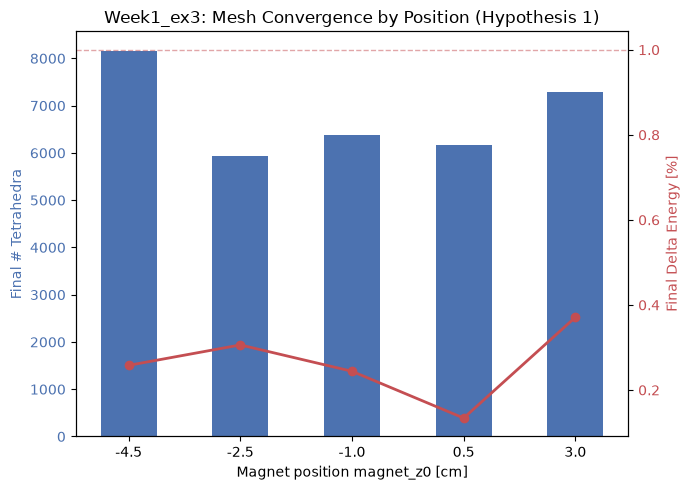

In [2]:
# 2. Convergence data, read once from Setup1 -> Convergence in the AEDT GUI per variation
h1 = pd.DataFrame([
    (-4.5, 4, 8164, 0.258),
    (-2.5, 3, 5931, 0.306),
    (-1.0, 3, 6388, 0.244),
    (0.5, 3, 6167, 0.134),
    (3.0, 4, 7287, 0.371),
], columns=["magnet_z0_cm", "completed_passes", "final_tetrahedra", "final_delta_energy_pct"])

fig, ax1 = plt.subplots(figsize=(7, 5))
ax1.bar(h1["magnet_z0_cm"].astype(str), h1["final_tetrahedra"], color="#4C72B0", width=0.5)
ax1.set_xlabel("Magnet position magnet_z0 [cm]")
ax1.set_ylabel("Final # Tetrahedra", color="#4C72B0")
ax1.tick_params(axis="y", labelcolor="#4C72B0")
ax1.set_title("Week1_ex3: Mesh Convergence by Position (Hypothesis 1)")

ax2 = ax1.twinx()
ax2.plot(h1["magnet_z0_cm"].astype(str), h1["final_delta_energy_pct"], color="#C44E52", marker="o", linewidth=2)
ax2.set_ylabel("Final Delta Energy [%]", color="#C44E52")
ax2.tick_params(axis="y", labelcolor="#C44E52")
ax2.axhline(1.0, color="#C44E52", linestyle="--", linewidth=1, alpha=0.5)

fig.tight_layout()
fig.savefig("Images/Week1_ex3_mesh_convergence_by_position.png", dpi=150, bbox_inches="tight")
plt.show()


**Hypothesis 1 rejected.** Every sampled position converges independently, running its own 3-4 adaptive passes and landing on its own tetrahedra count (5931 to 8164) -- there's no sign of a frozen mesh being reused. And the nominal point isn't even the best-converged one: -1cm lands at 0.244% Delta Energy while 0.5cm converges tighter at 0.134% and 3cm looser at 0.371%. If mesh reuse from the nominal point were the cause, -1cm should stand out as uniquely accurate; instead it's unremarkable. Mesh convergence quality has no relationship to which positions show the largest force anomaly.

## Hypothesis 2: proximity to the finite Region boundary

`Region` approximates free space with a padded box (`pad_value=50`, `pad_type='Percentage Offset'`), not true infinite space. If the magnet's self-force is being computed against this finite boundary instead of true free space, the force should behave like a boundary-proximity (image-force-style) effect: strongest when the magnet sits closest to a Region wall, and pushing away from whichever wall is nearer.

**Region's bounding box formula**, confirmed by querying `Region.bounding_box` in AEDT at three positions (-5cm, -1cm, 3cm) and reverse-engineering the padding rule from the results:

```
combined_z_span = [min(magnet_z0, coil_z_min), max(magnet_z0 + magnet_height, coil_z_max)]
pad = 0.5 * span(combined_z_span)
region_z = [combined_min - pad, combined_max + pad]
```

with `coil_z = [-2.5, 2.5]` and `magnet_height = 2`. This reproduces all three GUI-confirmed bounding boxes exactly, so it's used below to compute the distance from the magnet to the nearer Region wall at all 17 sweep points -- purely arithmetic, no AEDT session needed.

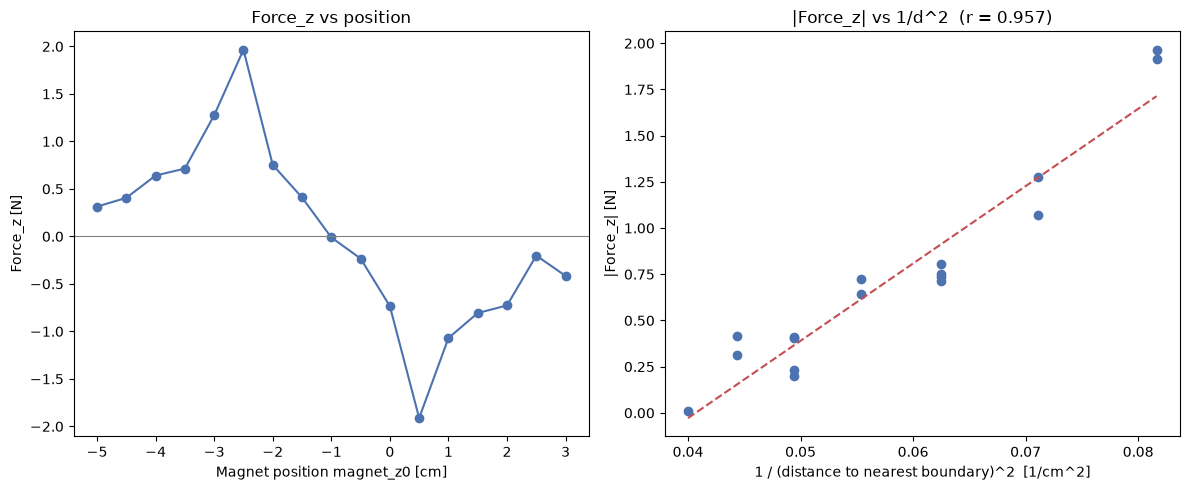

In [3]:
# 3. Region bounding box formula, confirmed against three GUI-queried points (-5cm, -1cm, 3cm)
def region_bounds(z0, coil_z=(-2.5, 2.5), magnet_height=2):
    combined_min = min(z0, coil_z[0])
    combined_max = max(z0 + magnet_height, coil_z[1])
    pad = 0.5 * (combined_max - combined_min)
    return combined_min - pad, combined_max + pad

# 4. Distance from the magnet center to the nearer Region wall, for every sweep point
rows = []
for z0, force in zip(df["magnet_z0_cm"], df["Force_z_N"]):
    rmin, rmax = region_bounds(z0)
    center = z0 + 1  # magnet spans [z0, z0+2], center at z0+1
    nearest = min(center - rmin, rmax - center)
    rows.append({"magnet_z0_cm": z0, "Force_z_N": force, "dist_to_nearest_boundary_cm": nearest})

df2 = pd.DataFrame(rows)

# 5. Correlation between |Force_z| and 1/distance^2 (image-force-style scaling)
d = df2["dist_to_nearest_boundary_cm"].values
f = df2["Force_z_N"].abs().values
inv2 = 1.0 / d**2
r = np.corrcoef(f, inv2)[0, 1]

fig, (axA, axB) = plt.subplots(1, 2, figsize=(12, 5))

axA.plot(df2["magnet_z0_cm"], df2["Force_z_N"], marker="o", color="#4C72B0")
axA.axhline(0, color="gray", linewidth=0.8)
axA.set_xlabel("Magnet position magnet_z0 [cm]")
axA.set_ylabel("Force_z [N]")
axA.set_title("Force_z vs position")

axB.scatter(inv2, f, color="#4C72B0")
coeffs = np.polyfit(inv2, f, 1)
xfit = np.linspace(inv2.min(), inv2.max(), 50)
axB.plot(xfit, np.polyval(coeffs, xfit), color="#C44E52", linestyle="--")
axB.set_xlabel("1 / (distance to nearest boundary)^2  [1/cm^2]")
axB.set_ylabel("|Force_z| [N]")
axB.set_title(f"|Force_z| vs 1/d^2  (r = {r:.3f})")

fig.tight_layout()
fig.savefig("Images/Week1_ex3_force_vs_boundary_distance.png", dpi=150, bbox_inches="tight")
plt.show()


**Hypothesis 2 confirmed.** The pattern lines up on every count:
- `Force_z` is smallest right where the magnet is farthest from any Region wall (magnet_z0 = -1cm, distance 5.0cm)
- both force peaks (-2.5cm and 0.5cm) land exactly where the magnet is closest to a wall (distance 3.5cm, the minimum across the whole sweep)
- the sign always points away from the nearer wall: magnet_z0 < -1cm is closer to the lower wall and Force_z is positive (pushed toward +z, away from that wall); magnet_z0 > -1cm is closer to the upper wall and Force_z is negative
- `|Force_z|` correlates with `1/distance^2` at r = 0.957 -- an image-force-style falloff, not noise

This is a boundary-proximity artifact, not a real physical interaction between the magnet and the coil.

## Conclusion

The theory from the top of this notebook was right on its own terms: an isolated magnet's self-force in true free space should be zero, and the copper tube (no excitation, non-magnetic) never actually participates in this Magnetostatic model. What breaks is the free-space assumption itself -- `Region`'s 50% padding isn't large enough here, so the magnet ends up close enough to the domain wall (as little as 3.5cm) for the finite boundary to leave a real, non-trivial imprint on the computed force, strong enough to swing `Force_z` by almost 4N across the sweep.

This also folds back into the notebook's known limitation: the original goal was flux linkage induced by the magnet moving through the coil, which had to be abandoned because Field Calculator expressions don't re-evaluate across a parametric sweep on the Student license (see `Week1_ex3.ipynb`). `Force_z` was the fallback metric precisely because it's cached automatically at solve time -- but with no excitation on the coil, it was never measuring the coil interaction the exercise originally wanted. It was measuring how close the magnet sits to an undersized simulation domain.